# Grupo 1 — Holt-Winters

### Estado desta análise

Configuração oficial do Grupo 1: **granularidade diária**, **treino 70% / teste 30%** (divisão cronológica, sem embaralhar), **seed 42**, previsão de **30 dias** com validação **walk-forward** de janela expansiva (29 origens, que cobrem todo o período de teste).

A fonte é o Excel tratado do Grupo 1 (`dados_tratados/base-tratada-1.xlsx`), selecionado por `BASE_NAME = 'base-tratada-1'` e resolvido para a chave do manifesto (`bitcoin`). **Não há agregação mensal neste notebook**: a série é diária do começo ao fim.

**Ordem de execução (sempre `Restart & Run All`):** importações → configuração global → configuração do Holt-Winters → carga → T04/T05 (sazonalidade) → T08 (walk-forward) → T09 (modelagem) → T16 (comparação por MAE) → T17 (resíduos) → conclusões.


## Importações e Configurações Padrão

In [1]:
import itertools
import json
import math
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller

warnings.filterwarnings('ignore')

## Configuração global

In [2]:
BASE_NAME = 'base-tratada-1'
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from preparacao_bases import carregar_base_tratada   # o sys.path precisa estar pronto ANTES deste import

DATA_FILENAME = f'{BASE_NAME}.xlsx'
TARGET_COLUMN = 'priceClose'

FREQUENCY = 'D'        # granularidade diária (metadados.frequencia = 'D')
SEED = 42
TRAIN_FRAC = 0.70      # treino 70% / teste 30%, divisão cronológica (sem embaralhar)
TEST_FRAC = round(1 - TRAIN_FRAC, 2)

random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)   # use RNG.* em simulações/bootstrap

# O manifesto indexa as bases pelo nome lógico (bitcoin, trafego, poluicao, clima, ouro).
_manifesto = json.loads((PROJECT_ROOT / 'dados_tratados' / 'manifesto.json').read_text(encoding='utf-8'))
BASE_KEY = next((nome for nome, item in _manifesto['bases'].items()
                 if item['excel'] == DATA_FILENAME), None)
assert BASE_KEY, f'Excel {DATA_FILENAME} não encontrado no manifesto.'

# Valida os parâmetros contra os metadados gravados na própria planilha
_meta = (pd.read_excel(PROJECT_ROOT / 'dados_tratados' / DATA_FILENAME, sheet_name='metadados')
           .set_index('campo')['valor'])
assert str(_meta['frequencia']) == FREQUENCY, f"Frequência da base: {_meta['frequencia']}"
assert int(_meta['seed']) == SEED, f"Seed da base: {_meta['seed']}"
assert math.isclose(float(_meta['treino']), TRAIN_FRAC), f"Treino da base: {_meta['treino']}"

print(f'Fonte: dados_tratados/{DATA_FILENAME} (chave do manifesto: {BASE_KEY})')
print(f'Freq={FREQUENCY} | seed={SEED} | treino/teste={TRAIN_FRAC:.0%}/{TEST_FRAC:.0%}')

Fonte: dados_tratados/base-tratada-1.xlsx (chave do manifesto: bitcoin)
Freq=D | seed=42 | treino/teste=70%/30%


## Configuração do Holt-Winters

In [3]:
# Modelo principal (base diária)
TREND = 'add'            # 'add', 'mul' ou None
SEASONAL = None          # diário: sem sazonalidade semanal significativa (ACF dos lags 7/14/30 dentro do limite;
                         # F_sazonal ≈ 0,01 na STL, T04/T05). As variantes sazonais são avaliadas só como comparação.
SEASONAL_PERIODS = 7     # ciclo semanal (STL, grid do SARIMA e variantes sazonais); 365 é inviável no statsmodels
DAMPED_TREND = True      # sem amortecimento a tendência é extrapolada linearmente e a previsão longa diverge
OPTIMIZED = True
USE_BOXCOX = False       # alternativa a testar: use_boxcox=0 (log) estabiliza a variância dos resíduos (T17)
INITIALIZATION_METHOD = 'heuristic'   # 'heuristic', 'estimated', 'legacy-heuristic' ou 'known'

# Exercício de tendência amortecida (φ fixo). Com dados diários, φ <= 0,95 já é praticamente o ingênuo
DAMPING_GRID = [0.99, 0.97, 0.95, 0.90, 0.80, 0.70]

# Avaliação com origem móvel (walk-forward), em DIAS
HORIZON = 30             # previsão de 30 dias à frente
ORIGIN_STEP = 30         # = HORIZON: janelas de teste sem sobreposição
N_ORIGINS = 29           # cobre o teste inteiro (máximo que cabe no teste; ver verificação na carga)
LONG_HORIZON = 365       # horizonte longo do exercício de amortecimento (confirmar no enunciado)

# Modelo de referência (SARIMA com grid search) — desligue se ficar lento
RUN_SARIMA = True

## Carga da base tratada

O Excel compartilhado é diário e é usado **sem agregação**. Duas séries são mantidas: `y_obs` (com os NaN originais do alvo, usada para **avaliar**) e `y` (com os dias faltantes do treino interpolados no tempo, usada apenas para **ajustar** os modelos). Todos os NaN do alvo estão no período de treino; o teste é 100% observado.

In [4]:
# Fonte comum T01; granularidade diária (sem agregação).
df, metadados_base = carregar_base_tratada(BASE_KEY, PROJECT_ROOT)
assert metadados_base['frequencia'] == FREQUENCY == 'D'

# Série observada: preserva os NaN (usada para AVALIAR)
y_obs = df[TARGET_COLUMN].astype(float).asfreq(FREQUENCY)
y_obs.index.name = 'data'

# Os NaN precisam estar todos no treino (70%); no teste o alvo tem de ser 100% observado
n_train = int(len(y_obs) * TRAIN_FRAC)
n_nan = int(y_obs.isna().sum())
assert y_obs.iloc[n_train:].notna().all(), 'Há NaN no período de teste.'

# Série para AJUSTAR o modelo: interpolação apenas nos dias faltantes do treino
y = y_obs.interpolate(method='time', limit_area='inside')
assert not y.isna().any()

if 'mul' in (TREND, SEASONAL) and (y <= 0).any():
    raise ValueError("Componente 'mul' exige série estritamente positiva.")

# Verifica que as janelas do walk-forward e o horizonte longo cabem no período de teste
N_TEST = len(y) - n_train
assert HORIZON + (N_ORIGINS - 1) * ORIGIN_STEP <= N_TEST, 'Janelas excedem o tamanho do teste.'
assert LONG_HORIZON <= N_TEST, 'LONG_HORIZON excede o tamanho do teste.'
MAX_ORIGINS = (N_TEST - HORIZON) // ORIGIN_STEP + 1
print(f'Teste: {N_TEST} dias | Horizonte={HORIZON}d | origens={N_ORIGINS} (máx. possível: {MAX_ORIGINS}) '
      f'| horizonte longo={LONG_HORIZON}d')

print(f'{len(y)} dias | {y.index.min():%Y-%m-%d} a {y.index.max():%Y-%m-%d} '
      f'| {n_nan} dias interpolados (só para ajuste; avaliação usa y_obs)')
y.head()

Teste: 884 dias | Horizonte=30d | origens=29 (máx. possível: 29) | horizonte longo=365d
2945 dias | 2018-08-22 a 2026-09-13 | 23 dias interpolados (só para ajuste; avaliação usa y_obs)


data
2018-08-22 12:00:00    6376.71
2018-08-23 12:00:00    6534.88
2018-08-24 12:00:00    6719.96
2018-08-25 12:00:00    6763.19
2018-08-26 12:00:00    6707.26
Freq: D, Name: priceClose, dtype: float64

# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL (sobre o log do preço, apenas no treino) e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

> **Nota (base bitcoin, diária):** o pico geral da ACF (lag 33) não é interpretável — num passeio aleatório a ACF das diferenças
> não tem pico sazonal. Nos lags candidatos (7, 14 e 30) a ACF fica dentro do limite de ±1,96/√n, ou seja, **não há evidência de
> ciclo semanal ou mensal**. ``SEASONAL_PERIODS = 7`` é mantido para a STL, para o grid do SARIMA e para as variantes sazonais do
> Holt-Winters, e a T05 confirma ``F_sazonal ≈ 0,01``: a série diária do bitcoin não tem ciclo semanal relevante.

Limite 95%: ±0.043
ACF nos candidatos: {7: -0.022, 14: 0.012, 30: 0.006}
Maior pico geral: lag 33 (ACF=0.053) — sem interpretação sazonal
Sem evidência de ciclo nos lags semanais/mensais: coerente com SEASONAL=None.
SEASONAL_PERIODS=7 (ciclo semanal), usado na STL e no grid do SARIMA.


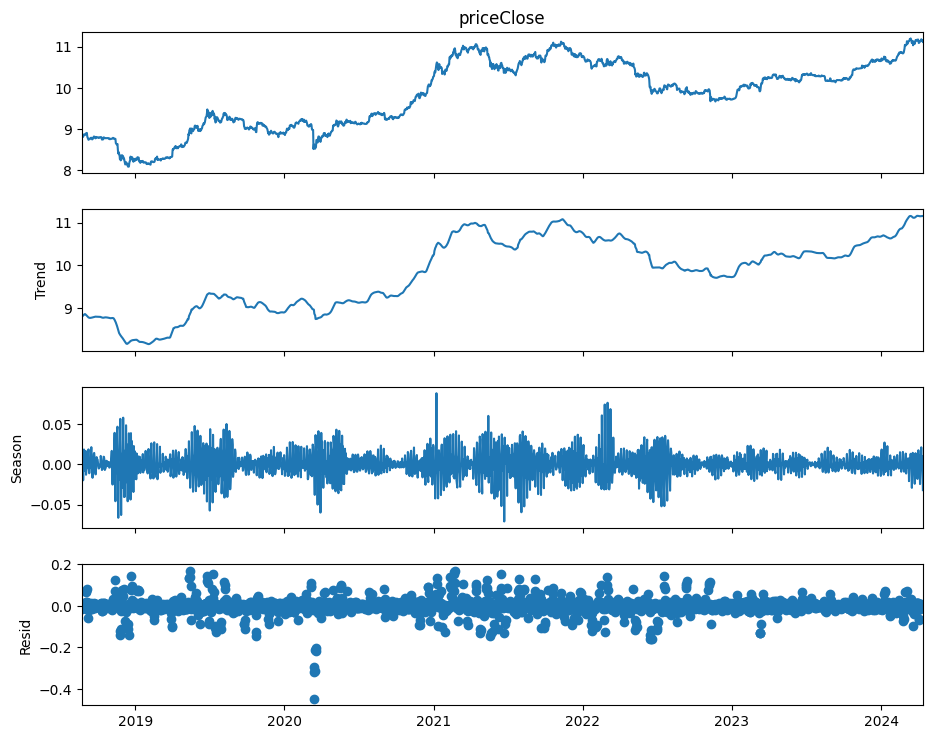

Força da tendência (F_tend) = 0.998 | Força da sazonalidade (F_saz) = 0.009


,tendencia_media,variacao_%,dias_no_ano
data,,,
2018,5627.20,NaN,132
2019,7393.21,31.38,365
2020,11119.86,50.41,366
2021,47207.68,324.53,365
2022,28247.94,-40.16,365
2023,28806.17,1.98,365
2024,55399.49,92.32,103


In [5]:
def detectar_periodo_sazonal(serie, max_lag=60, candidatos=(7, 14, 30)):
    """Confere SEASONAL_PERIODS na série diferenciada (remove a tendência).

    Devolve um dicionário com o lag de maior ACF, o limite de 95% (±1,96/sqrt(n)) e a ACF
    nos candidatos. Só há evidência de sazonalidade se algum candidato superar o limite;
    o pico geral pode ser ruído (muitos lags testados).
    """
    dif = serie.diff().dropna()
    n = len(dif)
    valores = acf(dif, nlags=max_lag, fft=True)
    limite = 1.96 / np.sqrt(n)
    lag_pico = int(np.argmax(valores[2:]) + 2)          # ignora lags 0 e 1
    acf_cand = {c: float(valores[c]) for c in candidatos if c <= max_lag}
    return {'lag_pico': lag_pico, 'acf_pico': float(valores[lag_pico]), 'limite': float(limite),
            'acf_candidatos': acf_cand, 'evidencia': any(v > limite for v in acf_cand.values())}

# Diagnóstico exploratório SÓ no treino (não usa o teste para decidir o modelo)
y_treino = y.iloc[:n_train]
y_log = np.log(y_treino)          # log: variações viram retornos e a tendência fica aditiva

res_acf = detectar_periodo_sazonal(y_log)
print(f"Limite 95%: ±{res_acf['limite']:.3f}")
print('ACF nos candidatos:', {k: round(v, 3) for k, v in res_acf['acf_candidatos'].items()})
print(f"Maior pico geral: lag {res_acf['lag_pico']} (ACF={res_acf['acf_pico']:.3f}) — sem interpretação sazonal")

if res_acf['evidencia'] and SEASONAL is None:
    print('ATENÇÃO: há evidência de sazonalidade, mas SEASONAL=None. Revise a configuração.')
elif not res_acf['evidencia']:
    print(f'Sem evidência de ciclo nos lags semanais/mensais: coerente com SEASONAL={SEASONAL}.')
print(f'SEASONAL_PERIODS={SEASONAL_PERIODS} (ciclo semanal), usado na STL e no grid do SARIMA.')

# Decomposição STL
stl_res = STL(y_log, period=SEASONAL_PERIODS, robust=True).fit()
fig = stl_res.plot()
fig.set_size_inches(10, 8)
plt.show()

# Força da tendência e da sazonalidade (Wang, Smith & Hyndman, 2006)
F_tend = max(0, 1 - stl_res.resid.var() / (stl_res.trend + stl_res.resid).var())
F_saz = max(0, 1 - stl_res.resid.var() / (stl_res.seasonal + stl_res.resid).var())
print(f'Força da tendência (F_tend) = {F_tend:.3f} | Força da sazonalidade (F_saz) = {F_saz:.3f}')

# Leitura numérica da tendência: alta / queda / estabilidade por ano (em preço)
tend_preco = np.exp(stl_res.trend)
g = tend_preco.groupby(tend_preco.index.year)
tend_anual = g.mean()
display(pd.DataFrame({'tendencia_media': tend_anual,
                      'variacao_%': tend_anual.pct_change() * 100,
                      'dias_no_ano': g.size()}).round(2))

## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Força da sazonalidade: 0.009
Força da tendência:    0.998
Anos completos usados: [2019, 2020, 2021, 2022, 2023] (n=5, amostra pequena)
Corr. amplitude × nível, escala log:   0.23 (perto de 0 => amplitude relativa constante => compatível com multiplicativa)
Corr. amplitude × nível, escala preço: 0.81 (esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)

Resíduo STL (log):


,resid
count,2061.0000
mean,-0.0004
std,0.0386
min,-0.4482
25%,-0.0098
50%,-0.0002
75%,0.0106
max,0.1703


Assimetria: -1.64 | Curtose em excesso: 18.85 (normal = 0)
Ljung-Box (autocorrelação do resíduo STL):


,lb_stat,lb_pvalue
7,1261.3308,0.0
14,1346.9810,0.0
30,1393.6088,0.0


Teste ARCH (variância não constante), p = 0.0000
Desvio padrão do resíduo por ano:


,std_resid
data,
2018,0.0391
2019,0.0375
2020,0.0483
2021,0.0457
2022,0.0378
2023,0.0200
2024,0.0271


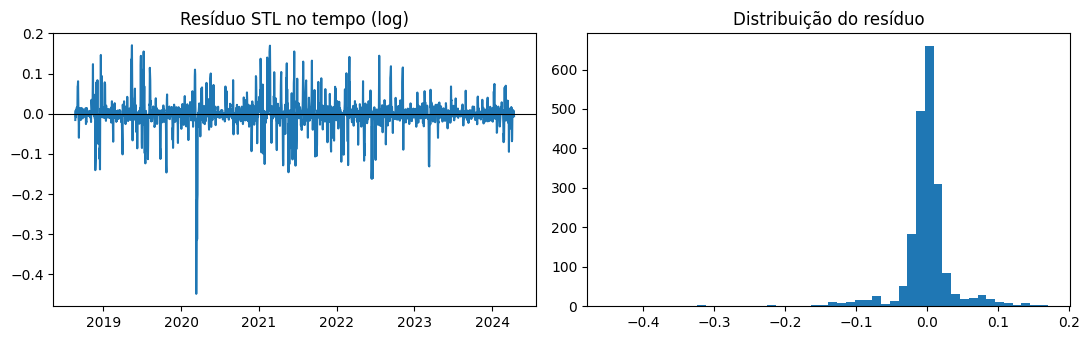

In [6]:
# T05 — Força da sazonalidade e resíduos
def forca(resid, componente):
    """Força (Hyndman): max(0, 1 - Var(R) / Var(componente + R)). Próxima de 1 => componente forte."""
    return max(0.0, 1 - np.var(resid) / np.var(componente + resid))

F_sazonal = forca(stl_res.resid, stl_res.seasonal)
F_tendencia = forca(stl_res.resid, stl_res.trend)
print(f'Força da sazonalidade: {F_sazonal:.3f}')
print(f'Força da tendência:    {F_tendencia:.3f}')

# Aditivo x multiplicativo. O STL está em LOG: sazonalidade multiplicativa => amplitude (em log) constante.
anos_completos = [a for a in stl_res.seasonal.index.year.unique()
                  if (stl_res.seasonal.index.year == a).sum() >= 365]
def amp_nivel(sazonal, tendencia):
    amp = sazonal.groupby(sazonal.index.year).agg(lambda s: s.max() - s.min())
    niv = tendencia.groupby(tendencia.index.year).mean()
    return amp, niv

amp_log, niv_log = amp_nivel(stl_res.seasonal, stl_res.trend)
tend_p = np.exp(stl_res.trend)
amp_p, niv_p = amp_nivel(tend_p * (np.exp(stl_res.seasonal) - 1), tend_p)
print(f'Anos completos usados: {anos_completos} (n={len(anos_completos)}, amostra pequena)')
print(f'Corr. amplitude × nível, escala log:   {amp_log.loc[anos_completos].corr(niv_log.loc[anos_completos]):.2f} '
      '(perto de 0 => amplitude relativa constante => compatível com multiplicativa)')
print(f'Corr. amplitude × nível, escala preço: {amp_p.loc[anos_completos].corr(niv_p.loc[anos_completos]):.2f} '
      '(esperado alto sob sazonalidade multiplicativa; F_saz ≈ 0 => conclusão fraca)')

# Componente residual (em log)
r = stl_res.resid
print('\nResíduo STL (log):')
display(r.describe().round(4).to_frame('resid'))
print(f'Assimetria: {stats.skew(r):.2f} | Curtose em excesso: {stats.kurtosis(r):.2f} (normal = 0)')
print('Ljung-Box (autocorrelação do resíduo STL):')
display(acorr_ljungbox(r, lags=[7, 14, 30]).round(4))
print(f'Teste ARCH (variância não constante), p = {het_arch(r, nlags=7)[1]:.4f}')
print('Desvio padrão do resíduo por ano:')
display(r.groupby(r.index.year).std().round(4).to_frame('std_resid'))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(r)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title('Resíduo STL no tempo (log)')
ax[1].hist(r, bins=50)
ax[1].set_title('Distribuição do resíduo')
plt.tight_layout()
plt.show()

# 3. Validação temporal

## T08 — Validação walk-forward

Protocolo walk-forward de janela expansiva. As origens partem do **corte treino/teste (70/30)** e avançam de `ORIGIN_STEP` em `ORIGIN_STEP` dias; cada janela de teste tem `HORIZON` dias e cabe inteira no período de teste. O hold-out simples é a própria partição 70/30 (2.061 dias de treino / 884 de teste).

In [7]:
# T08 — Validação walk-forward (janela expansiva)
def make_origins(n_obs, n_train, horizon, n_origins, step):
    """Tamanhos de treino (origens), a partir do corte treino/teste (70/30).
    Cada janela de teste cabe dentro do período de teste."""
    origens = [n_train + k * step for k in range(n_origins)]
    assert origens[-1] + horizon <= n_obs, (
        f'As {n_origins} origens com passo {step} excedem a base; máximo = {(n_obs - n_train - horizon) // step + 1}.')
    return origens


def walk_forward(serie, forecast_fn, origins, horizon):
    """Para cada origem: ajusta só com o passado e prevê `horizon` passos à frente."""
    partes = []
    for o in origins:
        treino, teste = serie.iloc[:o], serie.iloc[o:o + horizon]
        assert len(teste) == horizon, f'Janela incompleta na origem {o}.'
        prev = np.asarray(forecast_fn(treino, horizon))
        partes.append(pd.DataFrame({
            'origem': treino.index[-1], 'data': teste.index, 'h': np.arange(1, horizon + 1),
            'y_real': teste.values, 'y_prev': prev,
        }))
    return pd.concat(partes, ignore_index=True)


n_train = int(len(y) * TRAIN_FRAC)                      # 2061
ORIGINS = make_origins(len(y), n_train, HORIZON, N_ORIGINS, ORIGIN_STEP)
assert ORIGINS[0] >= 2 * SEASONAL_PERIODS, 'Treino da 1ª origem menor que 2 ciclos sazonais.'
# O alvo do teste não pode ter sido interpolado (todos os NaN estão no treino)
assert y_obs.iloc[ORIGINS[0]:].notna().all(), 'Há NaN do alvo dentro das janelas de teste.'

# Hold-out simples = partição 70/30 da base (2.061 treino / 884 teste)
train, test = y.iloc[:n_train], y.iloc[n_train:]

display(pd.DataFrame([{
    'fold': i + 1, 'n_treino': o, 'treino_ate': y.index[o - 1].date(),
    'teste_de': y.index[o].date(), 'teste_ate': y.index[o + HORIZON - 1].date(),
} for i, o in enumerate(ORIGINS)]))

,fold,n_treino,treino_ate,teste_de,teste_ate
0,1,2061,2024-04-12,2024-04-13,2024-05-12
1,2,2091,2024-05-12,2024-05-13,2024-06-11
2,3,2121,2024-06-11,2024-06-12,2024-07-11
3,4,2151,2024-07-11,2024-07-12,2024-08-10
4,5,2181,2024-08-10,2024-08-11,2024-09-09
5,6,2211,2024-09-09,2024-09-10,2024-10-09
6,7,2241,2024-10-09,2024-10-10,2024-11-08
7,8,2271,2024-11-08,2024-11-09,2024-12-08
8,9,2301,2024-12-08,2024-12-09,2025-01-07
9,10,2331,2025-01-07,2025-01-08,2025-02-06


# 4. Modelagem Holt-Winters

## T09 — Holt-Winters

Modelo principal: **Holt com tendência aditiva amortecida e sem sazonalidade** (a sazonalidade semanal não é sustentada pelos dados, ver T04/T05). A família Holt-Winters completa (sazonalidade aditiva e multiplicativa, período 7) e o SES são ajustados como comparação, junto com as referências ingênuas. Esta seção: (1) ajuste no treino e parâmetros α, β, γ e φ; (2) walk-forward de todos os modelos com as **mesmas origens**; (3) sensibilidade ao amortecimento; (4) SARIMA como referência.

In [8]:
def ajustar_hw(serie, trend=TREND, seasonal=SEASONAL, damped=DAMPED_TREND, damping_trend=None,
               seasonal_periods=SEASONAL_PERIODS, use_boxcox=USE_BOXCOX):
    """Ajusta um Holt-Winters com os padrões da configuração; qualquer argumento pode ser sobrescrito."""
    modelo = ExponentialSmoothing(
        serie, trend=trend, damped_trend=bool(damped and trend), seasonal=seasonal,
        seasonal_periods=seasonal_periods if seasonal else None,
        use_boxcox=use_boxcox, initialization_method=INITIALIZATION_METHOD)
    kw = {'optimized': OPTIMIZED}
    if damping_trend is not None:
        kw['damping_trend'] = damping_trend      # φ fixo (exercício de sensibilidade)
    return modelo.fit(**kw)


def parametros(fit):
    """Parâmetros de suavização estimados: α (nível), β (tendência), γ (sazonal) e φ (amortecimento)."""
    p = fit.params
    return {'alpha': p.get('smoothing_level'), 'beta': p.get('smoothing_trend'),
            'gamma': p.get('smoothing_seasonal'), 'phi': p.get('damping_trend')}


# Ajustes no treino (hold-out 70/30). Mesmo treino de 2.061 dias para todos os modelos
_hw = lambda **kw: ExponentialSmoothing(train, initialization_method=INITIALIZATION_METHOD, **kw).fit()
fits_holdout = {
    'SES (sem tend./saz.)': _hw(),
    'HW aditivo': _hw(trend='add', seasonal='add', seasonal_periods=SEASONAL_PERIODS),
    'HW multiplicativo': _hw(trend='add', seasonal='mul', seasonal_periods=SEASONAL_PERIODS),
    'HW multiplicativo amortecido': _hw(trend='add', damped_trend=True, seasonal='mul', seasonal_periods=SEASONAL_PERIODS),
}
assert all(len(f.resid) == n_train for f in fits_holdout.values()), \
    'fits_holdout foi ajustado com outra janela de treino.'
fit_cfg = ajustar_hw(train)             # modelo configurado (TREND / SEASONAL / DAMPED_TREND)

tabela_param = pd.DataFrame({
    nome: {**parametros(f), 'AIC': f.aic}
    for nome, f in {**fits_holdout, 'Holt amortecido (configurado)': fit_cfg}.items()
}).T
print('Parâmetros estimados no treino (α≈1 => o nível acompanha quase só o último valor):')
display(tabela_param.round(4))

Parâmetros estimados no treino (α≈1 => o nível acompanha quase só o último valor):


,alpha,beta,gamma,phi,AIC
SES (sem tend./saz.),0.9475,NaN,NaN,NaN,28710.6002
HW aditivo,0.9483,0.0000,0.0063,NaN,28729.4487
HW multiplicativo,0.9507,0.0000,0.0082,NaN,28726.8034
HW multiplicativo amortecido,0.9372,0.0127,0.0080,0.9690,28725.4851
Holt amortecido (configurado),0.9324,0.0135,NaN,0.9671,28711.7286


In [9]:
# Walk-forward de todos os modelos, com as MESMAS origens e horizonte
def hw_forecaster(**kw):
    def f(treino, h):
        return ExponentialSmoothing(treino, initialization_method=INITIALIZATION_METHOD, **kw).fit().forecast(h)
    return f

def naive_forecaster(treino, h):
    return np.repeat(treino.iloc[-1], h)                    # repete o último valor

def naive_drift_forecaster(treino, h):
    deriva = (treino.iloc[-1] - treino.iloc[0]) / (len(treino) - 1)   # variação média diária
    return treino.iloc[-1] + deriva * np.arange(1, h + 1)

modelos = {
    'SES (sem tend./saz.)': hw_forecaster(),
    'HW aditivo': hw_forecaster(trend='add', seasonal='add', seasonal_periods=SEASONAL_PERIODS),
    'HW multiplicativo': hw_forecaster(trend='add', seasonal='mul', seasonal_periods=SEASONAL_PERIODS),
    'HW multiplicativo amortecido': hw_forecaster(trend='add', damped_trend=True,
                                                  seasonal='mul', seasonal_periods=SEASONAL_PERIODS),
    'Holt amortecido (sem saz.)': hw_forecaster(trend='add', damped_trend=True),
    'Ingênuo': naive_forecaster,
    'Ingênuo c/ deriva': naive_drift_forecaster,
}
wf_resultados = {nome: walk_forward(y, f, ORIGINS, HORIZON) for nome, f in modelos.items()}

# Alarmes: mesmas origens, sem NaN
_ref = set(next(iter(wf_resultados.values()))['origem'])
assert len(_ref) == N_ORIGINS
assert all(set(d['origem']) == _ref for d in wf_resultados.values()), 'Modelos com origens diferentes.'
assert all(d[['y_real', 'y_prev']].notna().all().all() for d in wf_resultados.values()), 'Há NaN nas previsões.'
print(f'{len(_ref)} folds | origens de {min(_ref):%Y-%m-%d} a {max(_ref):%Y-%m-%d} | {len(wf_resultados)} modelos')

29 folds | origens de 2024-04-12 a 2026-07-31 | 7 modelos


### Sensibilidade da tendência amortecida (φ)

Sem amortecimento a tendência é somada linearmente e a previsão diverge com o horizonte. Com ``damped_trend=True`` cada passo
futuro da tendência é multiplicado por uma potência de φ (0 < φ < 1). Compara-se φ estimado por MLE com φ fixo, em um horizonte longo.

,phi,valor_ultimo_dia,variacao_%_vs_sem_damping,AIC,RMSE,MAE,MAPE_%
0,sem damping,109256.89,0.00,28715.37,15980.52,13122.93,19.26
1,MLE (0.9671),68004.34,-37.76,28711.73,17761.97,13568.23,15.98
2,0.99,75420.18,-30.97,28713.20,14812.79,12647.02,16.11
3,0.97,68254.55,-37.53,28711.74,17641.10,13539.10,15.99
4,0.95,67304.53,-38.40,28711.91,18107.81,13664.83,15.96
5,0.9,67036.23,-38.64,28712.31,18242.61,13703.81,15.95
6,0.8,67043.83,-38.64,28711.99,18237.89,13698.30,15.95
7,0.7,67075.96,-38.61,28711.97,18221.38,13692.25,15.94
8,ingênuo,67195.86,-38.50,NaN,18160.85,13674.26,15.95


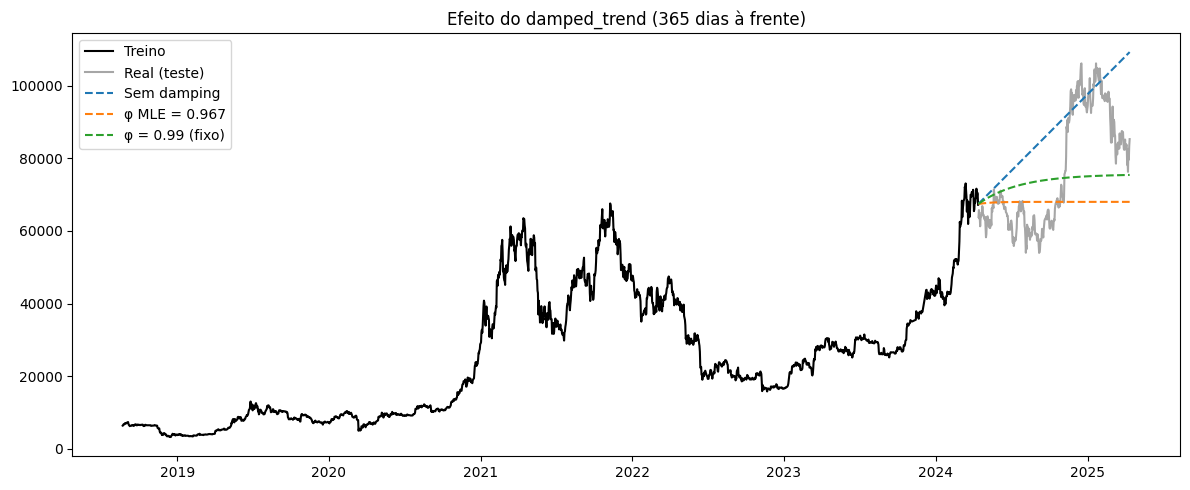

In [10]:
# Efeito do damped_trend — só avaliação; φ NÃO é escolhido olhando o teste
real_h = y_obs.iloc[n_train:n_train + LONG_HORIZON]
assert len(real_h) == LONG_HORIZON and real_h.notna().all(), 'LONG_HORIZON excede o teste ou há NaN.'

def metricas(fc):
    e = real_h.values - fc.values
    return {'RMSE': np.sqrt((e ** 2).mean()), 'MAE': np.abs(e).mean(),
            'MAPE_%': (np.abs(e) / real_h.values).mean() * 100}

sem_damping = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=False)
mle = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True)
phi_mle = parametros(mle)['phi']

fc_base = sem_damping.forecast(LONG_HORIZON)
fc_mle = mle.forecast(LONG_HORIZON)
valor_base = fc_base.iloc[-1]
fc_naive = pd.Series(np.repeat(train.iloc[-1], LONG_HORIZON), index=fc_base.index)

linhas = [
    {'phi': 'sem damping', 'valor_ultimo_dia': valor_base, 'variacao_%_vs_sem_damping': 0.0,
     'AIC': sem_damping.aic, **metricas(fc_base)},
    {'phi': f'MLE ({phi_mle:.4f})', 'valor_ultimo_dia': fc_mle.iloc[-1],
     'variacao_%_vs_sem_damping': (fc_mle.iloc[-1] / valor_base - 1) * 100,
     'AIC': mle.aic, **metricas(fc_mle)},
]
fc_fixos = {}
for phi in DAMPING_GRID:
    fit = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True, damping_trend=phi)
    fc_fixos[phi] = fit.forecast(LONG_HORIZON)
    linhas.append({'phi': phi, 'valor_ultimo_dia': fc_fixos[phi].iloc[-1],
                   'variacao_%_vs_sem_damping': (fc_fixos[phi].iloc[-1] / valor_base - 1) * 100,
                   'AIC': fit.aic, **metricas(fc_fixos[phi])})
linhas.append({'phi': 'ingênuo', 'valor_ultimo_dia': fc_naive.iloc[-1],
               'variacao_%_vs_sem_damping': (fc_naive.iloc[-1] / valor_base - 1) * 100,
               'AIC': np.nan, **metricas(fc_naive)})
display(pd.DataFrame(linhas).round(2))

phi_plot = 0.99 if 0.99 in fc_fixos else DAMPING_GRID[0]   # distinto do MLE no gráfico
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, color='black', label='Treino')
plt.plot(real_h.index, real_h.values, color='gray', alpha=0.7, label='Real (teste)')
plt.plot(fc_base.index, fc_base.values, ls='--', label='Sem damping')
plt.plot(fc_mle.index, fc_mle.values, ls='--', label=f'φ MLE = {phi_mle:.3f}')
plt.plot(fc_fixos[phi_plot].index, fc_fixos[phi_plot].values, ls='--', label=f'φ = {phi_plot} (fixo)')
plt.legend()
plt.title(f'Efeito do damped_trend ({LONG_HORIZON} dias à frente)')
plt.tight_layout()
plt.show()

### Modelo de referência — SARIMA (grid search)

Grid reduzido e justificado pela série: **d = 1** (o ADF indica raiz unitária no preço e estacionariedade na primeira diferença), **D = 0** (não há ciclo semanal), p, q ∈ 0–2 e P, Q ∈ 0–1 com m = ``SEASONAL_PERIODS``, mais a opção sem componente sazonal.
Para não vazar informação do futuro, o grid é feito só com o treino da **primeira origem** (o treino original de 2.061 dias) e a ordem escolhida fica congelada
para todos os folds (o MAE do teste não entra na escolha).

> **Atenção ao critério (AIC):** o `aic` do `SARIMAX` **não é comparável** entre modelos com componentes sazonais diferentes, porque cada um descarta um número
> diferente de observações iniciais no cálculo da verossimilhança (`loglikelihood_burn`: 4 sem termo sazonal contra 10–11 com). Isso fazia um termo sazonal
> com coeficiente ≈ 0 parecer ganhar ~109 pontos de AIC. Aqui o AIC é recalculado descartando as **mesmas** `2·m` observações iniciais de todos os modelos (`AIC_comparavel`).

In [11]:
if RUN_SARIMA:
    treino_grid = y.iloc[:ORIGINS[0]]          # só o treino original (2.061 dias)

    # d=1 e D=0 justificados por testes no treino
    print(f'ADF (H0: raiz unitária) — nível: p={adfuller(treino_grid)[1]:.4f} | '
          f'1ª diferença: p={adfuller(treino_grid.diff().dropna())[1]:.4f}')
    pdq = [(p, 1, q) for p, q in itertools.product(range(3), range(3))]
    # sem sazonalidade (0,0,0,0) + variantes semanais, para comparar; não há ciclo semanal na STL/ACF
    sazonal_pdq = [(0, 0, 0, 0)] + [(P, 0, Q, SEASONAL_PERIODS)
                                    for P, Q in itertools.product(range(2), range(2)) if (P, Q) != (0, 0)]

    BURN_COMUM = 2 * SEASONAL_PERIODS          # mesmas observações iniciais descartadas em todos os modelos
    resultados, falhas = [], 0
    for order in pdq:
        for seasonal_order in sazonal_pdq:
            try:
                res = SARIMAX(treino_grid, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                ll = np.nansum(res.llf_obs[BURN_COMUM:])
                resultados.append({'order': order, 'seasonal_order': seasonal_order,
                                   'AIC_comparavel': -2 * ll + 2 * len(res.params),
                                   'AIC_statsmodels': res.aic, 'burn': res.model.loglikelihood_burn})
            except Exception:
                falhas += 1
    print(f'{len(resultados)} modelos ajustados, {falhas} falhas')

    grid_sarima = pd.DataFrame(resultados).sort_values('AIC_comparavel').reset_index(drop=True)
    assert grid_sarima['burn'].max() <= BURN_COMUM, 'BURN_COMUM menor que o burn de algum modelo.'
    display(grid_sarima.head(10).round(1))
    melhor = grid_sarima.iloc[0]
    print(f"Escolhido: order={melhor['order']}, seasonal_order={melhor['seasonal_order']}")

    def sarima_forecaster(treino, h):
        return SARIMAX(treino, order=melhor['order'], seasonal_order=melhor['seasonal_order'],
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).forecast(h)

    wf_resultados['SARIMA (grid AIC)'] = walk_forward(y, sarima_forecaster, ORIGINS, HORIZON)

ADF (H0: raiz unitária) — nível: p=0.8551 | 1ª diferença: p=0.0000
36 modelos ajustados, 0 falhas


,order,seasonal_order,AIC_comparavel,AIC_statsmodels,burn
0,"(2, 1, 2)","(0, 0, 0, 0)",34335.1,34493.8,4
1,"(2, 1, 2)","(1, 0, 0, 7)",34336.6,34400.1,10
2,"(2, 1, 2)","(0, 0, 1, 7)",34336.7,34384.3,11
3,"(2, 1, 2)","(1, 0, 1, 7)",34337.2,34385.5,11
4,"(1, 1, 2)","(0, 0, 0, 0)",34337.9,34495.9,4
5,"(1, 1, 0)","(0, 0, 0, 0)",34338.4,34527.8,2
6,"(0, 1, 1)","(0, 0, 0, 0)",34338.5,34512.1,3
7,"(1, 1, 2)","(1, 0, 0, 7)",34339.0,34418.2,9
8,"(1, 1, 2)","(0, 0, 1, 7)",34339.2,34386.7,11
9,"(2, 1, 1)","(1, 0, 0, 7)",34339.3,34403.1,10


Escolhido: order=(2, 1, 2), seasonal_order=(0, 0, 0, 0)


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

MAE por fold:


,SES (sem tend./saz.),HW aditivo,HW multiplicativo,HW multiplicativo amortecido,Holt amortecido (sem saz.),Ingênuo,Ingênuo c/ deriva,SARIMA (grid AIC)
fold 1 (origem 2024-04-12),4244.79,5014.50,5084.84,4747.45,4523.90,4093.16,4550.78,4022.43
fold 2 (origem 2024-05-12),6722.01,6087.18,5997.56,6964.02,7031.86,6688.54,6280.12,6663.15
fold 3 (origem 2024-06-11),5584.06,6335.74,6278.74,5652.33,5625.65,5465.25,5909.00,5495.86
fold 4 (origem 2024-07-11),6383.11,5922.63,5989.56,6889.98,6850.36,6402.20,6158.02,6361.47
fold 5 (origem 2024-08-10),2695.00,3212.44,3330.11,2958.14,2586.46,2696.43,2972.34,3053.86
fold 6 (origem 2024-09-09),4998.47,4421.29,4418.28,5329.09,5292.98,4879.17,4523.99,4816.57
fold 7 (origem 2024-10-09),7750.08,7115.73,7254.80,8005.37,7815.85,7822.15,7448.68,7913.90
fold 8 (origem 2024-11-08),17140.69,16412.40,16361.72,16170.78,16258.68,17112.59,16633.46,16960.05
fold 9 (origem 2024-12-08),3982.21,4496.86,4665.11,6170.62,5971.81,4013.63,4507.89,6129.46
fold 10 (origem 2025-01-07),4303.78,3938.21,3953.48,4089.78,4080.86,4382.80,4031.39,4313.34


Resumo (29 folds):


,base,MAE_medio,MAE_ultimo_fold,vitorias,posicao_media,MAE_vs_ingenuo_%,folds_melhor_que_ingenuo
Ingênuo c/ deriva,base-tratada-1.xlsx,6116.79,6107.66,1,4.24,0.01,15
HW aditivo,base-tratada-1.xlsx,6112.92,5692.38,6,4.34,-0.05,14
Holt amortecido (sem saz.),base-tratada-1.xlsx,6183.43,6421.14,5,4.41,1.10,14
Ingênuo,base-tratada-1.xlsx,6115.98,6374.78,1,4.45,0.00,0
SES (sem tend./saz.),base-tratada-1.xlsx,6138.73,6303.47,3,4.45,0.37,13
HW multiplicativo,base-tratada-1.xlsx,6145.36,5691.79,6,4.55,0.48,15
SARIMA (grid AIC),base-tratada-1.xlsx,6207.74,6308.53,2,4.55,1.50,16
HW multiplicativo amortecido,base-tratada-1.xlsx,6223.74,6338.45,5,5.00,1.76,13


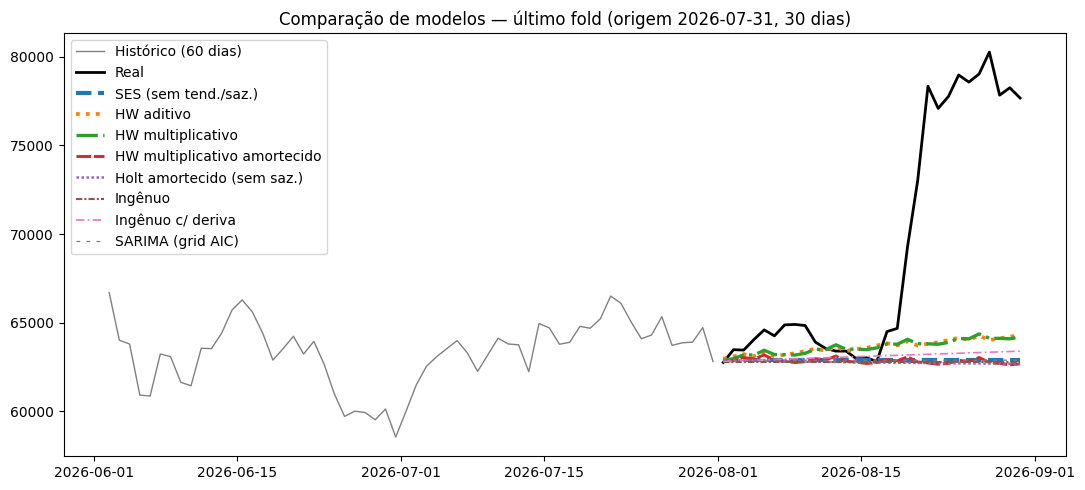

In [12]:
# T16 — Comparação por MAE (fora da amostra, walk-forward)
tabela_mae = pd.DataFrame({
    nome: {origem: mean_absolute_error(d['y_real'], d['y_prev']) for origem, d in df_wf.groupby('origem')}
    for nome, df_wf in wf_resultados.items()
})
assert not tabela_mae.isna().any().any(), 'Há NaN: modelos com origens diferentes — regenere o wf_resultados.'
origens_idx = tabela_mae.index                                   # guarda as datas reais
tabela_mae.index = [f'fold {i + 1} (origem {o:%Y-%m-%d})' for i, o in enumerate(origens_idx)]
print('MAE por fold:')
display(tabela_mae.round(2))

posicoes = tabela_mae.rank(axis=1, method='min')                 # 1 = melhor no fold
resumo = pd.DataFrame({
    'base': DATA_FILENAME,
    'MAE_medio': tabela_mae.mean(),
    'MAE_ultimo_fold': tabela_mae.iloc[-1],
    'vitorias': (posicoes == 1).sum(),
    'posicao_media': posicoes.mean(),
})
REF = 'Ingênuo'                                                  # ajuste ao nome usado em wf_resultados
assert REF in tabela_mae.columns, f'Inclua {REF} em wf_resultados (referência da comparação).'
resumo['MAE_vs_ingenuo_%'] = (resumo['MAE_medio'] / tabela_mae[REF].mean() - 1) * 100
resumo['folds_melhor_que_ingenuo'] = tabela_mae.lt(tabela_mae[REF], axis=0).sum()
resumo = resumo.sort_values(['posicao_media', 'MAE_medio'])
print(f'Resumo ({len(tabela_mae)} folds):')
display(resumo.round(2))

# Gráfico do último fold: real e previsões na MESMA janela (30 dias) + 60 dias de contexto
ultimo = origens_idx.max()
real_ult = next(iter(wf_resultados.values())).query('origem == @ultimo')
plt.figure(figsize=(11, 5))
plt.plot(y.loc[:ultimo].iloc[-60:].index, y.loc[:ultimo].iloc[-60:].values, color='gray', lw=1, label='Histórico (60 dias)')
plt.plot(real_ult['data'], real_ult['y_real'], color='black', lw=2, label='Real')
estilos = ['--', ':', '-.', (0, (5, 1)), (0, (1, 1)), (0, (3, 1, 1, 1)), (0, (5, 2, 1, 2)), (0, (3, 5))]
for i, (nome, df_wf) in enumerate(wf_resultados.items()):   # estilos/espessuras distintos: as curvas planas se sobrepõem
    d = df_wf[df_wf['origem'] == ultimo]
    plt.plot(d['data'], d['y_prev'], ls=estilos[i % len(estilos)], lw=3 - 0.3 * i, label=nome)
plt.legend()
plt.title(f'Comparação de modelos — último fold (origem {ultimo:%Y-%m-%d}, {HORIZON} dias)')
plt.tight_layout()
plt.show()

## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

Modelo configurado: trend=add, seasonal=None, damped=True | n resíduos = 2061


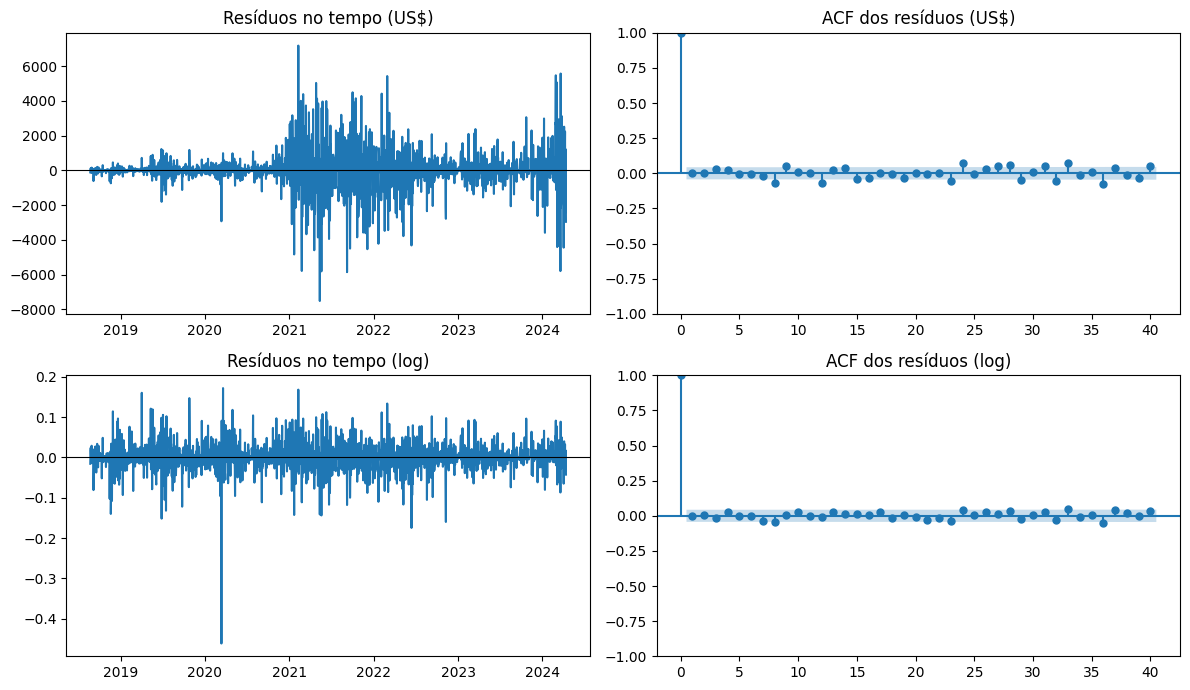

p-valores do teste de Ljung-Box:


,lag 7,lag 14,lag 30
SES (sem tend./saz.),0.4013,0.0008,0.000
HW aditivo,0.3945,0.0012,0.000
HW multiplicativo,0.3721,0.0014,0.000
HW multiplicativo amortecido,0.6560,0.0037,0.000
Holt amortecido (configurado),0.7545,0.0026,0.000
Holt amortecido (log),0.6679,0.5760,0.482


Desvio padrão dos resíduos por ano:


,std_US$,std_log
data,,
2018,168.4755,0.0348
2019,315.9500,0.0353
2020,405.2340,0.0398
2021,1905.6006,0.0419
2022,1016.2647,0.0337
2023,627.9157,0.0222
2024,1861.3597,0.0313


In [13]:
# T17 — Diagnóstico dos resíduos (granularidade diária)
# Garante que é o treino DIÁRIO (2.061 dias) e não uma série de outra execução
assert len(train) == n_train and pd.infer_freq(train.index) == 'D', \
    'train não é a série diária: rode o notebook inteiro na ordem (Restart & Run All).'

# Modelo configurado, em US$ e em log (o log estabiliza a variância)
resid = fit_cfg.resid                  # modelo configurado, ajustado na T09 (TREND / SEASONAL / DAMPED_TREND)
fit_log = ExponentialSmoothing(np.log(train), trend=TREND, seasonal=SEASONAL,
                               seasonal_periods=SEASONAL_PERIODS if SEASONAL else None,
                               damped_trend=DAMPED_TREND,
                               initialization_method=INITIALIZATION_METHOD).fit(optimized=OPTIMIZED)
resid_log = fit_log.resid
print(f'Modelo configurado: trend={TREND}, seasonal={SEASONAL}, damped={DAMPED_TREND} | n resíduos = {len(resid)}')

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].plot(resid)
ax[0, 0].axhline(0, color='k', lw=0.8)
ax[0, 0].set_title('Resíduos no tempo (US$)')
plot_acf(resid, lags=40, ax=ax[0, 1])
ax[0, 1].set_title('ACF dos resíduos (US$)')
ax[1, 0].plot(resid_log)
ax[1, 0].axhline(0, color='k', lw=0.8)
ax[1, 0].set_title('Resíduos no tempo (log)')
plot_acf(resid_log, lags=40, ax=ax[1, 1])
ax[1, 1].set_title('ACF dos resíduos (log)')
plt.tight_layout()
plt.show()

# Ljung-Box (H0: resíduos sem autocorrelação; p < 0.05 => rejeita H0). Lags diários: semana, quinzena, mês
LAGS = [l for l in (7, 14, 30) if l <= len(resid) // 3]
modelos_lb = {**fits_holdout,
              'Holt amortecido (configurado)': fit_cfg,
              'Holt amortecido (log)': fit_log}
tabela_lb = pd.DataFrame({
    nome: acorr_ljungbox(f.resid, lags=LAGS, return_df=True)['lb_pvalue']
    for nome, f in modelos_lb.items()
}).T
tabela_lb.columns = [f'lag {l}' for l in LAGS]
print('p-valores do teste de Ljung-Box:')
display(tabela_lb.round(4))

# A variância dos resíduos é constante ao longo do tempo?
print('Desvio padrão dos resíduos por ano:')
display(pd.DataFrame({'std_US$': resid.groupby(resid.index.year).std(),
                      'std_log': resid_log.groupby(resid_log.index.year).std()}).round(4))

## Contexto das conclusões: mudança de nível entre treino e teste

In [14]:
# O teste contém valores que o treino nunca viu: contexto para interpretar os erros altos de previsão
display(pd.DataFrame({'treino': train.describe(), 'teste': y_obs.iloc[n_train:].describe()}).round(0))

,treino,teste
count,2061.0,884.0
mean,24907.0,83824.0
std,17474.0,18973.0
min,3237.0,53949.0
25%,9244.0,66001.0
50%,21528.0,81350.0
75%,38117.0,99399.0
max,73084.0,124753.0


## Conclusões e limitações

1. **Sazonalidade.** Nos lags 7, 14 e 30 a ACF das diferenças (−0,022, 0,012 e 0,006) fica dentro do limite de ±0,043, a força sazonal da STL é ≈ 0,009 e o grid do SARIMA (com AIC comparável) escolhe o modelo **sem** componente sazonal. Por isso o modelo principal é o **Holt com tendência aditiva amortecida, sem sazonalidade**; as variantes sazonais (período 7) servem de comparação. O correto é dizer que *não foi encontrada evidência* de sazonalidade, e não que ela não existe.
2. **Parâmetros.** α ≈ 0,93 (o nível acompanha quase só o último valor), β ≈ 0,014 e φ ≈ 0,967. O AIC do Holt amortecido (28.711,7) é praticamente igual ao do SES (28.710,6) e 14 a 18 pontos melhor que o dos Holt-Winters sazonais (28.725 a 28.729). Com α tão alto, o modelo se comporta quase como o ingênuo.
3. **Tendência amortecida.** Sem amortecimento, a previsão a 365 dias chega a ≈ 109,3 mil; com φ estimado, converge para ≈ 68,0 mil. O AIC favorece o amortecimento (28.711,7 contra 28.715,4). No teste de 365 dias a versão sem amortecimento teve RMSE menor (15.981 contra 17.762) porque o preço subiu no período, mas MAPE pior (19,3% contra 16,0%): é efeito do regime do período, e **não** critério para escolher φ. Para φ ≤ 0,95 as previsões ficam praticamente iguais às do ingênuo (≈ 67 mil).
4. **Walk-forward (29 folds, 30 dias).** Os modelos da família Holt-Winters ficam entre −0,05% e +1,8% do MAE do ingênuo (≈ 6.116) e o SARIMA em +1,5%; nenhum vence o ingênuo em mais de 16 dos 29 folds. **Não há evidência de ganho preditivo** em relação a repetir o último valor, o que é esperado para séries de preço de ativos, próximas de um passeio aleatório.
5. **Resíduos.** Em US$ a variância cresce (desvio de 168 em 2018 a 1.906 em 2021) e o Ljung-Box rejeita nos lags 14 e 30. Em log, o desvio fica entre 0,022 e 0,042 e o Ljung-Box **não rejeita** (p = 0,67, 0,58 e 0,48 nos lags 7, 14 e 30): resíduos compatíveis com ruído branco. Ainda há caudas pesadas e volatilidade variável (STL: curtose em excesso 18,85; crash de março de 2020), então intervalos de previsão baseados em erro normal ficam otimistas.
6. **Limitações.**
   - **Mudança de nível:** o teste atinge valores que o treino nunca viu (ver tabela acima).
   - **Interpolação:** 23 dias sem alvo (set–dez/2023) foram interpolados **somente para ajustar** os modelos; as métricas usam `y_obs`.
   - **Parâmetros de projeto:** horizonte de 30 dias e `LONG_HORIZON = 365` são decisões a confirmar no enunciado.
   - **Significância:** não foi aplicado teste formal de comparação de previsões (por exemplo, Diebold-Mariano), então diferenças de 1% a 2% no MAE não devem ser tratadas como significativas.

# Checklist antes do commit

- [ ] Configuração e versão da execução atualizadas.
- [ ] Separação temporal e horizonte documentados.
- [ ] Transformadores ajustados somente com dados de treino.
- [ ] Hiperparâmetros congelados antes do teste final.
- [ ] Métricas calculadas com previsões fora da amostra.
- [ ] Artefatos essenciais salvos por tarefa.
- [ ] Saídas excessivas e células temporárias removidas.